#EDA

---



In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Merge data/twt_comments.csv'

df = pd.read_csv(file_path)

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  4238 non-null   object
dtypes: object(1)
memory usage: 33.2+ KB


(4238, 1)

In [5]:
df.head()

,comment
0,Warga bagi-bagi dollar dari brankas sahroni.
1,·
2,·
3,·
4,·


##Analisis Missing Values

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df)) * 100
})

print(missing_df)

   Jumlah Missing  Persentase (%)
0               0             0.0


##Analisis Duplicate Data

In [7]:
duplicate_count = df['comment'].duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")


duplicates = df[df.duplicated()]
print(duplicates[['comment']])

Jumlah data duplikat: 2075
                                                comment
2                                                     ·
3                                                     ·
4                                                     ·
5                                                     ·
6                                                     ·
...                                                 ...
4230  This seems only way to expose arrogant politic...
4231                                               Liaw
4233  Indonesian mobs are doing it the way the Frenc...
4235                    They hauling a whole piano out.
4236                             Revolutions are so fun

[2075 rows x 1 columns]


##Analisis Noise

In [8]:
# Pastikan data string
df.columns = df.columns.str.strip()

print(df.columns)

Index(['comment'], dtype='object')


Deteksi URL

In [9]:
import re

url_pattern = r'http\S+|www\S+'

df['contains_url'] = df['comment'].apply(
    lambda x: bool(re.search(url_pattern, str(x)))
)

print(df['contains_url'].value_counts())

print(df[df['contains_url']]['comment'].head())

contains_url
False    4235
True        3
Name: count, dtype: int64
286     wowwww deket gangnya abubasteak ya? mandar kah...
436     hahhh?? truss sri mul sekeluarga ga dirumah?? ...
2442    Wowwww ga apa2 itu uang rakyat juga jadi silah...
Name: comment, dtype: object


Deteksi Hashtag

In [10]:
hashtag_pattern = r'#\w+'

df['contains_hashtag'] = df['comment'].apply(
    lambda x: bool(re.search(hashtag_pattern, str(x)))
)

print(df['contains_hashtag'].value_counts())

print(df[df['contains_hashtag']]['comment'])

contains_hashtag
False    4227
True       11
Name: count, dtype: int64
380     Public enemy #1 : sri mulyani
1738                    #kaburajadulu
2835                           #NAME?
2873                    #SonoraUpdate
2875                    #SonoraUpdate
2879                    #SonoraUpdate
3414                            #Foto
3845                            #SOON
3857                        #deserves
3889                      #StopAnarki
3979                     #BubarkanDPR
Name: comment, dtype: object


Deteksi Mention

In [11]:
mention_pattern = r'@\w+'

df['contains_mention'] = df['comment'].apply(
    lambda x: bool(re.search(mention_pattern, str(x)))
    if pd.notnull(x) else False
)

print(df['contains_mention'].value_counts())

df[df['contains_mention']]

contains_mention
False    4229
True        9
Name: count, dtype: int64


,comment,contains_url,contains_hashtag,contains_mention
2628,@AP,False,False,True
2629,@AP,False,False,True
2695,@StopPlandemit,False,False,True
2940,@DeanaMarsz sahroni kelar sih,False,False,True
2976,Join ga @imanlagi,False,False,True
3847,@imanlagi,False,False,True
3852,@prabowo,False,False,True
3854,@prabowo,False,False,True
3978,@rrm0ca,False,False,True


Deteksi Emoji

In [12]:
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticon
    u"\U0001F300-\U0001F5FF"  # simbol & pictograph
    u"\U0001F680-\U0001F6FF"  # transport
    u"\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

df['contains_emoji'] = df['comment'].apply(
    lambda x: bool(emoji_pattern.search(str(x)))
)

print(df['contains_emoji'].value_counts())

print(df[df['contains_emoji']]['comment'])

contains_emoji
False    4238
Name: count, dtype: int64
Series([], Name: comment, dtype: object)


Deteksi Simbol Berlebih

In [13]:
symbol_pattern = r'[^\w\s]'

df['contains_symbol'] = df['comment'].apply(
    lambda x: bool(re.search(symbol_pattern, str(x)))
)

print(df['contains_symbol'].value_counts())

print(df[df['contains_symbol']]['comment'].head())

contains_symbol
True     2905
False    1333
Name: count, dtype: int64
0    Warga bagi-bagi dollar dari brankas sahroni.
1                                               ·
2                                               ·
3                                               ·
4                                               ·
Name: comment, dtype: object


Deteksi Karakter Berulang
*   baguusssss
*   mantapppp



In [14]:
repeat_pattern = r'(.)\1{4,}'

df['contains_repeated_char'] = df['comment'].apply(
    lambda x: bool(re.search(repeat_pattern, str(x).lower()))
)

print(df['contains_repeated_char'].value_counts())

print(df[df['contains_repeated_char']]['comment'].head())


contains_repeated_char
False    4177
True       61
Name: count, dtype: int64
306    Kalo menteri dari artis yg modal tenar doang m...
351    masa iya sekelas mentri ga ada yg jagain????? ...
395                                            Whoaaaaaa
418    Ini Mandar lhooooo gua pernah tinggal disana h...
468                          Really ? \nSo blessed......
Name: comment, dtype: object


Deteksi Teks Irrelevant
*   terlalu pendek
*   hanya angka/simbol



In [15]:
def irrelevant_text(text):

    text = str(text).strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya angka/simbol
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

df['irrelevant_text'] = df['comment'].apply(irrelevant_text)

print(df['irrelevant_text'].value_counts())

print(df[df['irrelevant_text']]['comment'])

irrelevant_text
False    2221
True     2017
Name: count, dtype: int64
1           ·
2           ·
3           ·
4           ·
5           ·
        ...  
3843    00:06
3850    00:12
3998        T
4057    00:08
4155        G
Name: comment, Length: 2017, dtype: object


Ringkasan Noise


===== RINGKASAN NOISE =====
          Jenis Noise  Jumlah
0          URL/Tautan       3
1             Hashtag      11
2             Mention       9
3   Karakter Berulang      61
4  Teks Tidak Relevan    2017


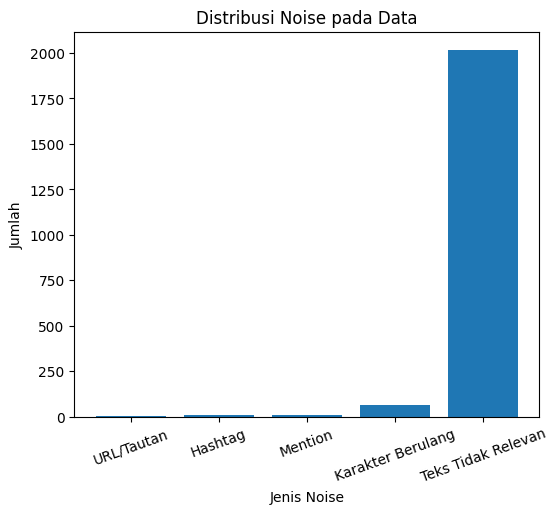

In [16]:
noise_summary = {
    'URL/Tautan': df['contains_url'].sum(),
    'Hashtag': df['contains_hashtag'].sum(),
    'Mention': df['contains_mention'].sum(),
    #'Emoji': df['contains_emoji'].sum(),
    #'Simbol': df['contains_symbol'].sum(),
    'Karakter Berulang': df['contains_repeated_char'].sum(),
    'Teks Tidak Relevan': df['irrelevant_text'].sum()
}

noise_df = pd.DataFrame(
    noise_summary.items(),
    columns=['Jenis Noise', 'Jumlah']
)

print("\n===== RINGKASAN NOISE =====")
print(noise_df)

# Visualisasi Noise
plt.figure(figsize=(6,5))
plt.bar(noise_df['Jenis Noise'], noise_df['Jumlah'])
plt.title('Distribusi Noise pada Data')
plt.xlabel('Jenis Noise')
plt.ylabel('Jumlah')
plt.xticks(rotation=20)
plt.show()

#PREPROCESSING

---



In [17]:
#copy dataset, agar data asli tidak berubah
clean_df = df.copy()

##Case Folding

In [18]:
clean_df['clean_text'] = clean_df['comment'].str.lower()
print(clean_df[['clean_text']].head())

                                     clean_text
0  warga bagi-bagi dollar dari brankas sahroni.
1                                             ·
2                                             ·
3                                             ·
4                                             ·


##Noise Removal

In [19]:
import re

def clean_noise(text):

    text = str(text)

    #hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    #hapus hashtag
    text = re.sub(r'#+w', '', text)

    #hapus mention
    text = re.sub(r'@+w', '', text)

    #hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

clean_df['clean_text'] = clean_df['clean_text'].apply(clean_noise)

##Cleaning Data

Hapus Missing Value

In [20]:
clean_df = clean_df.dropna(subset=['comment'])

print("Jumlah data setelah hapus missing value:")
print(len(clean_df))

Jumlah data setelah hapus missing value:
4238


Hapus Duplikat Data

In [21]:
clean_df = clean_df.drop_duplicates(subset=['comment'])

print("\nJumlah data setelah hapus duplikat:")
print(len(clean_df))


Jumlah data setelah hapus duplikat:
2163


Hapus Teks tidak Relevan

In [22]:
def irrelevant_text(text):

    text = text.strip()

    # terlalu pendek
    if len(text) < 3:
        return True

    # hanya simbol/angka
    if re.fullmatch(r'[\W\d_]+', text):
        return True

    return False

clean_df = clean_df[
    ~clean_df['comment'].apply(irrelevant_text)
]

print(len(clean_df))

2128


##Normalisasi

Ubah Karakter Berulang

In [23]:
def normalize_repeated_char(word):

    word = re.sub(r'(.)\1{2,}', r'\1', word)

    return word


def normalize_text(text):

    words = text.split()

    normalized_words = [
        normalize_repeated_char(word)
        for word in words
    ]

    return ' '.join(normalized_words)

clean_df['clean_text'] = clean_df['clean_text'].apply(normalize_text)
print(clean_df[['clean_text']].head())

                                            clean_text
0         warga bagi-bagi dollar dari brankas sahroni.
270                              terjemahkan postingan
271  man it was around 1.30ish and the satpam only ...
272  guys i also don’t know ada provokatornya atau ...
273  and i just wanted go home capek coy udah jam s...


#HASIL

In [24]:
print("\n===== HASIL PREPROCESSING =====")

print(clean_df[['comment', 'clean_text']].head(10))

print("\nJumlah data akhir:")
print(len(clean_df))


===== HASIL PREPROCESSING =====
                                               comment  \
0         Warga bagi-bagi dollar dari brankas sahroni.   
270                              Terjemahkan postingan   
271  man it was around 1.30ish and the satpam only ...   
272  guys i also don’t know ada provokatornya atau ...   
273  and i just wanted go home capek coy udah jam s...   
274  OIYA just to add up, tadi gue sm suami gue awa...   
275  nih deh gue share full nya aja anjir biar ga s...   
276                                                woi   
277  ga masuk akal bgt situasi mencekam gini tp seo...   
278  Guys, please stop ngejarah yaa, cukup. Thank y...   

                                            clean_text  
0         warga bagi-bagi dollar dari brankas sahroni.  
270                              terjemahkan postingan  
271  man it was around 1.30ish and the satpam only ...  
272  guys i also don’t know ada provokatornya atau ...  
273  and i just wanted go home capek coy ud

#SIMPAN HASIL

In [25]:
import os

final_df = clean_df[['clean_text']].copy()

# ubah nama kolom
final_df.columns = ['twt_clean']

In [26]:
folder_path = '/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Clean data'

os.makedirs(folder_path, exist_ok=True)

Simpan ke gdrive

In [27]:
output_path = f'{folder_path}/twt_clean.csv'

final_df.to_csv(output_path, index=False)

print("File berhasil disimpan di:")
print(output_path)

File berhasil disimpan di:
/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Clean data/twt_clean.csv


Download

In [28]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#DISTRIBUSI JUMLAH KATA TIAP KOMENTAR

---



In [29]:
# ======================================
# Distribusi Panjang Komentar
# ======================================

# Hitung jumlah kata pada setiap komentar
clean_df['word_count'] = clean_df['clean_text'].apply(
    lambda x: len(str(x).split())
)

# Hitung jumlah komentar pada setiap rentang
less_50 = (clean_df['word_count'] < 50).sum()
between_50_99 = ((clean_df['word_count'] >= 50) & (clean_df['word_count'] < 100)).sum()
between_100_199 = ((clean_df['word_count'] >= 100) & (clean_df['word_count'] < 200)).sum()
more_equal_200 = (clean_df['word_count'] >= 200).sum()

total = len(clean_df)

print("Distribusi Panjang Komentar")
print("="*40)
print(f"< 50 kata      : {less_50} komentar ({less_50/total*100:.2f}%)")
print(f"50-99 kata     : {between_50_99} komentar ({between_50_99/total*100:.2f}%)")
print(f"100-199 kata   : {between_100_199} komentar ({between_100_199/total*100:.2f}%)")
print(f"≥ 200 kata     : {more_equal_200} komentar ({more_equal_200/total*100:.2f}%)")

Distribusi Panjang Komentar
< 50 kata      : 2127 komentar (99.95%)
50-99 kata     : 1 komentar (0.05%)
100-199 kata   : 0 komentar (0.00%)
≥ 200 kata     : 0 komentar (0.00%)
